In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
DATA_DIR = Path("/Users/giannispapias/Desktop/TEF EV 2/ECC2/Data")  
OUT_CSV  = DATA_DIR / "ECC_master_PV_EMOB1_EMOB2_15min.csv"

In [3]:
# PODs
PV_POD    = "LU0000010669300000000000770597826"
EMOB1_POD = "LU0000010669300000000000070591610"
EMOB2_POD = "LU0000010669300000000000070620104"

# OBIS mapping
OBIS = {
    # PV meter
    "PV_prod":   "1-1:2.29.0",   # total PV production
    "PV_shared": "1-65:2.29.3",  # production shared within L2 group
    "PV_sold":   "1-65:2.29.9",  # remaining production sold/exported

    # EMOB meters
    "EV_cons":   "1-1:1.29.0",   # measured EV consumption
    "EV_cov":    "1-65:1.29.3",  # consumption covered by PV sharing
    "EV_inv":    "1-65:1.29.9",  # remaining consumption invoiced (grid)
}

In [ ]:
def read_ts_csv(path: Path) -> pd.DataFrame:
    """Read Leneda time-series CSV with delimiter auto-detection."""
    df = pd.read_csv(path, sep=None, engine="python", encoding="utf-8-sig")
    df.columns = [c.strip() for c in df.columns]
    return df

def find_value_col(df: pd.DataFrame) -> str:
    """Find the Value(...) column (e.g. 'Value (1-1:1.29.0)')"""
    val_cols = [c for c in df.columns if str(c).strip().lower().startswith("value")]
    if len(val_cols) != 1:
        raise ValueError(f"Expected 1 Value column, found {val_cols}")
    return val_cols[0]

def load_signal_for_pod(data_dir: Path, pod: str, obis: str, out_col: str) -> pd.DataFrame:
    """
    Find the CSV for (pod, obis) and return a clean dataframe:
    ['Started at', out_col] aggregated by timestamp if needed.
    """
    all_csvs = list(data_dir.glob("*.csv"))
    pod_files = [p for p in all_csvs if pod in p.name]

    if not pod_files:
        raise FileNotFoundError(f"No CSV files found for POD={pod} in {data_dir}")

    chosen = None
    for p in pod_files:
        df = read_ts_csv(p)
        if "OBIS code" in df.columns and (df["OBIS code"] == obis).any():
            chosen = p
            break

    if chosen is None:
        raise FileNotFoundError(f"No CSV found for POD={pod} containing OBIS={obis}")

    df = read_ts_csv(chosen)
    val_col = find_value_col(df)

    out = df[["Started at", val_col]].copy()
    out.rename(columns={val_col: out_col}, inplace=True)

    out["Started at"] = pd.to_datetime(out["Started at"], errors="coerce")
    out[out_col] = pd.to_numeric(out[out_col], errors="coerce")
    out = out.dropna(subset=["Started at"]).sort_values("Started at")

    out = out.groupby("Started at", as_index=False)[out_col].sum()
    return out

In [ ]:
# --- PV signals ---
pv_prod   = load_signal_for_pod(DATA_DIR, PV_POD, OBIS["PV_prod"],   "PV_TotalProduction_kW")
pv_shared = load_signal_for_pod(DATA_DIR, PV_POD, OBIS["PV_shared"], "PV_SharedToGroup_kW")
pv_sold   = load_signal_for_pod(DATA_DIR, PV_POD, OBIS["PV_sold"],   "PV_RemainingSold_kW")

# --- EMOB1 signals ---
e1_cons = load_signal_for_pod(DATA_DIR, EMOB1_POD, OBIS["EV_cons"], "EMOB1_EV_Consumption_kW")
e1_cov  = load_signal_for_pod(DATA_DIR, EMOB1_POD, OBIS["EV_cov"],  "EMOB1_CoveredByPV_kW")
e1_inv  = load_signal_for_pod(DATA_DIR, EMOB1_POD, OBIS["EV_inv"],  "EMOB1_RemainingInvoiced_kW")

# --- EMOB2 signals ---
e2_cons = load_signal_for_pod(DATA_DIR, EMOB2_POD, OBIS["EV_cons"], "EMOB2_EV_Consumption_kW")
e2_cov  = load_signal_for_pod(DATA_DIR, EMOB2_POD, OBIS["EV_cov"],  "EMOB2_CoveredByPV_kW")
e2_inv  = load_signal_for_pod(DATA_DIR, EMOB2_POD, OBIS["EV_inv"],  "EMOB2_RemainingInvoiced_kW")

/var/folders/c_/s52xjfl94q3dkt93cgtvs0p80000gn/T/ipykernel_55775/3843712154.py:41: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  out["Started at"] = pd.to_datetime(out["Started at"], errors="coerce")
/var/folders/c_/s52xjfl94q3dkt93cgtvs0p80000gn/T/ipykernel_55775/3843712154.py:41: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  out["Started at"] = pd.to_datetime(out["Started at"], errors="coerce")
/var/folders/c_/s52xjfl94q3dkt93cgtvs0p80000gn/T

In [ ]:
df = pv_prod.merge(pv_shared, on="Started at", how="outer") \
           .merge(pv_sold,   on="Started at", how="outer") \
           .merge(e1_cons,   on="Started at", how="outer") \
           .merge(e1_cov,    on="Started at", how="outer") \
           .merge(e1_inv,    on="Started at", how="outer") \
           .merge(e2_cons,   on="Started at", how="outer") \
           .merge(e2_cov,    on="Started at", how="outer") \
           .merge(e2_inv,    on="Started at", how="outer") \
           .sort_values("Started at")

In [ ]:
df["EV_TotalConsumption_kW"] = df["EMOB1_EV_Consumption_kW"] + df["EMOB2_EV_Consumption_kW"]
df["EV_TotalCoveredByPV_kW"] = df["EMOB1_CoveredByPV_kW"] + df["EMOB2_CoveredByPV_kW"]
df["EV_TotalInvoiced_kW"]    = df["EMOB1_RemainingInvoiced_kW"] + df["EMOB2_RemainingInvoiced_kW"]

df["PV_SurplusSold_kW"] = df["PV_RemainingSold_kW"]          
df["PV_UsedInsideGroup_kW"] = df["PV_SharedToGroup_kW"]      

In [ ]:
df["QA_PV"] = df["PV_TotalProduction_kW"] - (df["PV_SharedToGroup_kW"] + df["PV_RemainingSold_kW"])
df["QA_EMOB1"] = df["EMOB1_EV_Consumption_kW"] - (df["EMOB1_CoveredByPV_kW"] + df["EMOB1_RemainingInvoiced_kW"])
df["QA_EMOB2"] = df["EMOB2_EV_Consumption_kW"] - (df["EMOB2_CoveredByPV_kW"] + df["EMOB2_RemainingInvoiced_kW"])

print("QA PV identity stats (prod = shared + sold):")
print(df["QA_PV"].describe())

print("\nQA EMOB1 identity stats (cons = covered + invoiced):")
print(df["QA_EMOB1"].describe())

print("\nQA EMOB2 identity stats (cons = covered + invoiced):")
print(df["QA_EMOB2"].describe())

QA PV identity stats (prod = shared + sold):
count    5.299600e+04
mean    -2.480384e-17
std      1.026101e-14
min     -1.136868e-13
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.136868e-13
Name: QA_PV, dtype: float64

QA EMOB1 identity stats (cons = covered + invoiced):
count    5.299600e+04
mean     2.702445e-19
std      3.035867e-15
min     -5.684342e-14
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      5.684342e-14
Name: QA_EMOB1, dtype: float64

QA EMOB2 identity stats (cons = covered + invoiced):
count    3.158400e+04
mean     7.153318e-18
std      1.878119e-15
min     -5.684342e-14
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      5.684342e-14
Name: QA_EMOB2, dtype: float64


In [ ]:
df.to_csv(OUT_CSV, index=False)
print(f"Saved master ECC dataset -> {OUT_CSV}")
df.head()

Saved master ECC dataset -> /Users/giannispapias/Desktop/TEF EV 2/ECC2/Data/ECC_master_PV_EMOB1_EMOB2_15min.csv


,Started at,PV_TotalProduction_kW,PV_SharedToGroup_kW,PV_RemainingSold_kW,EMOB1_EV_Consumption_kW,EMOB1_CoveredByPV_kW,EMOB1_RemainingInvoiced_kW,EMOB2_EV_Consumption_kW,EMOB2_CoveredByPV_kW,EMOB2_RemainingInvoiced_kW,EV_TotalConsumption_kW,EV_TotalCoveredByPV_kW,EV_TotalInvoiced_kW,PV_SurplusSold_kW,PV_UsedInsideGroup_kW,QA_PV,QA_EMOB1,QA_EMOB2
0,2023-01-01 00:00:00+01:00,NaN,NaN,NaN,0.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2023-01-01 00:15:00+01:00,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2023-01-01 00:30:00+01:00,NaN,NaN,NaN,0.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2023-01-01 00:45:00+01:00,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2023-01-01 01:00:00+01:00,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


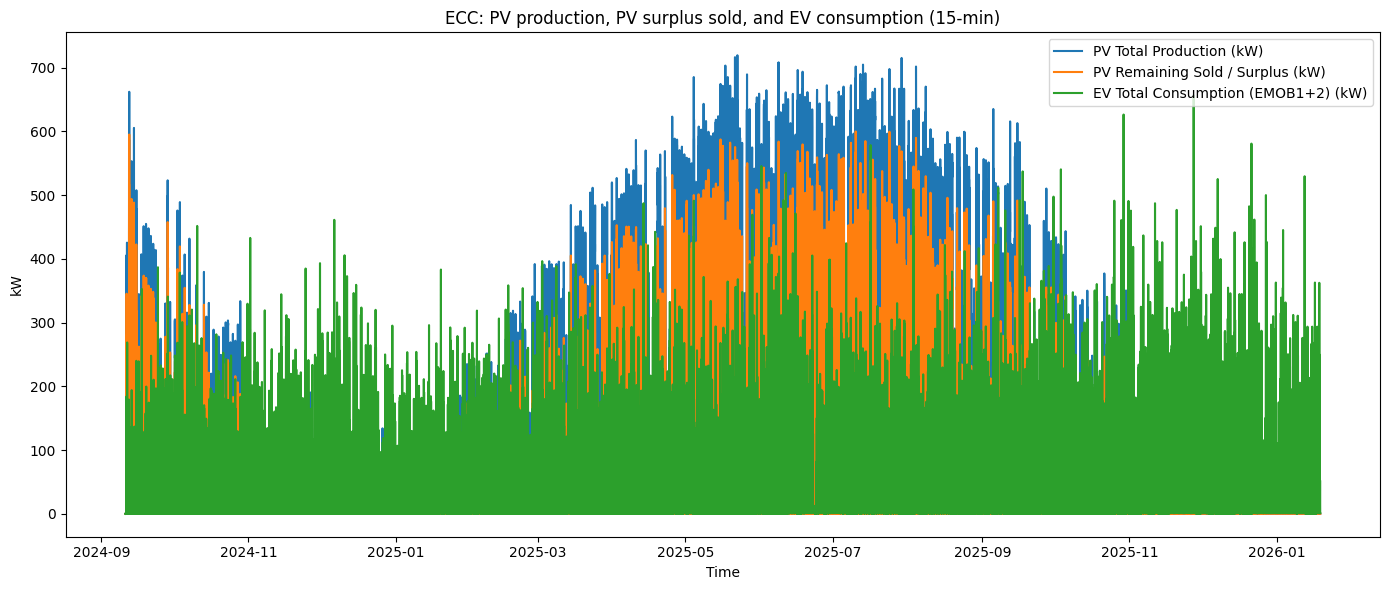

In [ ]:
plot_df = df.dropna(subset=["PV_TotalProduction_kW", "EV_TotalConsumption_kW"]).copy()

plt.figure(figsize=(14,6))
plt.plot(plot_df["Started at"], plot_df["PV_TotalProduction_kW"], label="PV Total Production (kW)")
plt.plot(plot_df["Started at"], plot_df["PV_SurplusSold_kW"], label="PV Remaining Sold / Surplus (kW)")
plt.plot(plot_df["Started at"], plot_df["EV_TotalConsumption_kW"], label="EV Total Consumption (EMOB1+2) (kW)")
plt.xlabel("Time")
plt.ylabel("kW")
plt.title("ECC: PV production, PV surplus sold, and EV consumption (15-min)")
plt.legend()
plt.tight_layout()
plt.show()

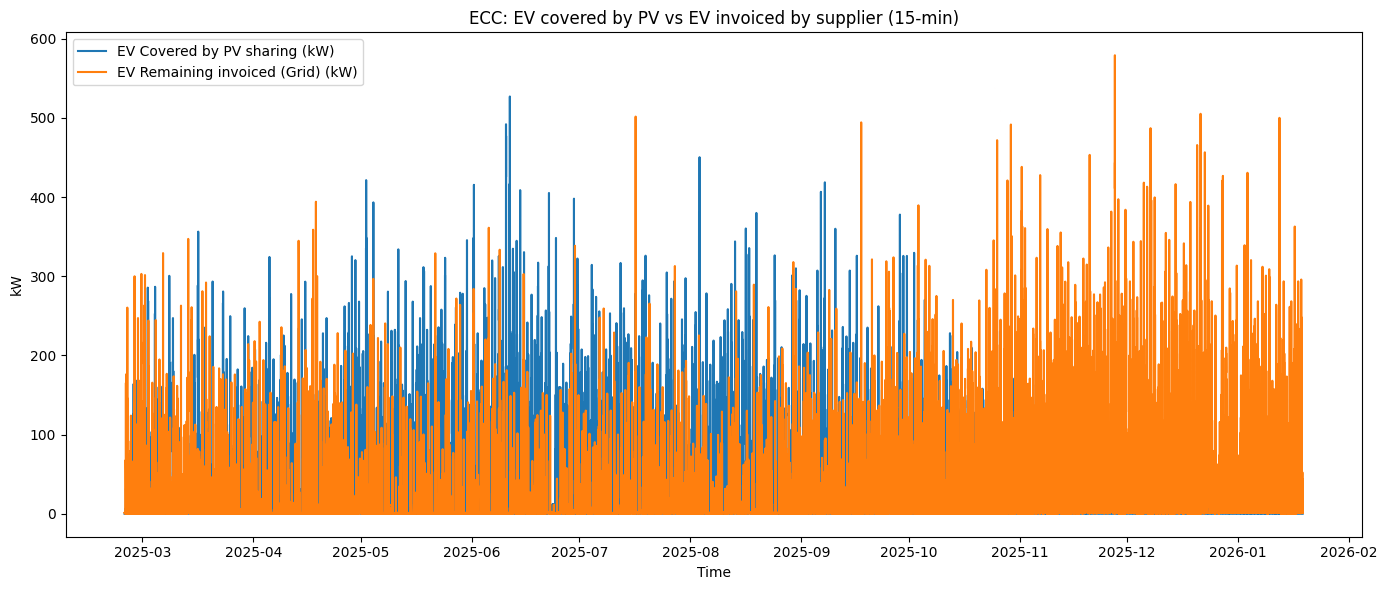

In [ ]:
plot_df2 = df.dropna(subset=["EV_TotalCoveredByPV_kW", "EV_TotalInvoiced_kW"]).copy()

plt.figure(figsize=(14,6))
plt.plot(plot_df2["Started at"], plot_df2["EV_TotalCoveredByPV_kW"], label="EV Covered by PV sharing (kW)")
plt.plot(plot_df2["Started at"], plot_df2["EV_TotalInvoiced_kW"], label="EV Remaining invoiced (Grid) (kW)")
plt.xlabel("Time")
plt.ylabel("kW")
plt.title("ECC: EV covered by PV vs EV invoiced by supplier (15-min)")
plt.legend()
plt.tight_layout()
plt.show()


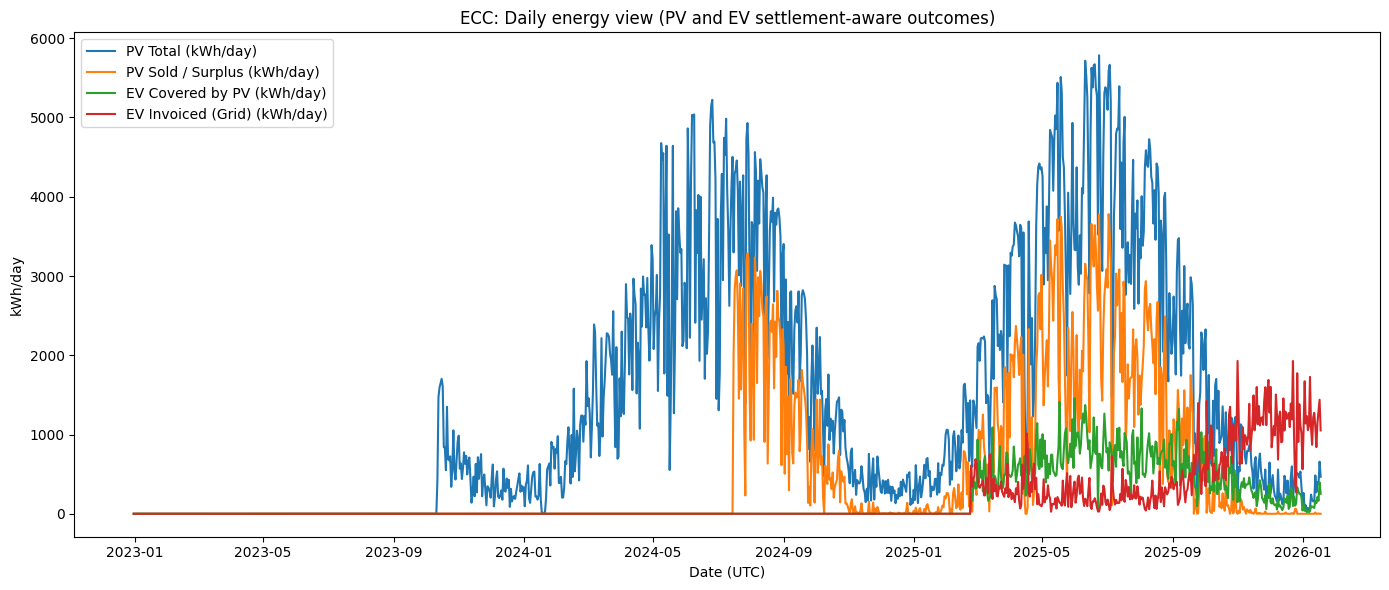

,date,PV_Total_kWh,PV_Sold_kWh,EV_Inv_kWh,EV_Cov_kWh
0,2022-12-31,0.0,0.0,0.0,0.0
1,2023-01-01,0.0,0.0,0.0,0.0
2,2023-01-02,0.0,0.0,0.0,0.0
3,2023-01-03,0.0,0.0,0.0,0.0
4,2023-01-04,0.0,0.0,0.0,0.0


In [ ]:
daily = df.copy()

daily["Started at"] = pd.to_datetime(daily["Started at"], utc=True, errors="coerce")

daily["date"] = daily["Started at"].dt.date

kwh_factor = 0.25  # 15 minutes

daily["PV_Total_kWh"] = daily["PV_TotalProduction_kW"] * kwh_factor
daily["PV_Sold_kWh"]  = daily["PV_RemainingSold_kW"]   * kwh_factor
daily["EV_Inv_kWh"]   = daily["EV_TotalInvoiced_kW"]   * kwh_factor
daily["EV_Cov_kWh"]   = daily["EV_TotalCoveredByPV_kW"]* kwh_factor

daily_agg = daily.groupby("date", as_index=False)[
    ["PV_Total_kWh","PV_Sold_kWh","EV_Inv_kWh","EV_Cov_kWh"]
].sum()

import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.plot(daily_agg["date"], daily_agg["PV_Total_kWh"], label="PV Total (kWh/day)")
plt.plot(daily_agg["date"], daily_agg["PV_Sold_kWh"],  label="PV Sold / Surplus (kWh/day)")
plt.plot(daily_agg["date"], daily_agg["EV_Cov_kWh"],   label="EV Covered by PV (kWh/day)")
plt.plot(daily_agg["date"], daily_agg["EV_Inv_kWh"],   label="EV Invoiced (Grid) (kWh/day)")
plt.xlabel("Date (UTC)")
plt.ylabel("kWh/day")
plt.title("ECC: Daily energy view (PV and EV settlement-aware outcomes)")
plt.legend()
plt.tight_layout()
plt.show()

daily_agg.head()
